In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv('3-customersatisfaction.csv')

In [4]:
df.head()

,Unnamed: 0,Customer Satisfaction,Incentive
0,0,-1.282447,1.010513
1,1,0.425298,2.281043
2,2,1.953070,4.415053
3,3,2.625838,10.563600
4,4,-1.426333,0.627365


In [5]:
df.drop('Unnamed: 0' , axis = 1 , inplace = True)

In [6]:
df.head()

,Customer Satisfaction,Incentive
0,-1.282447,1.010513
1,0.425298,2.281043
2,1.953070,4.415053
3,2.625838,10.563600
4,-1.426333,0.627365


# DATAYI PARÇALA

In [7]:
X = df[['Customer Satisfaction']]
y = df['Incentive']

# Train - Test Split

In [8]:
 X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 15)

# Preprocessing - Scaler

In [9]:
scaler = StandardScaler()

In [10]:
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Regression - Ogrenme

In [11]:
regression = LinearRegression()

In [12]:
regression.fit(X_train , y_train)

LinearRegression()

# Doğruluk Testi

In [13]:
y_pred = regression.predict(X_test)

In [14]:
score = r2_score(y_test , y_pred)
print(score) 

0.2705652535622246


# %27 doğruluk oranına sahip birde grafik üzerinde best fit line a bakalım

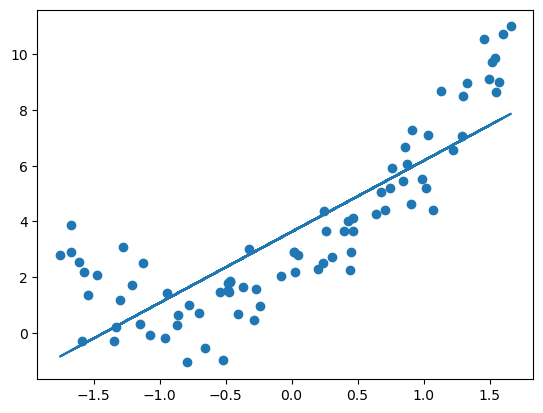

In [15]:
plt.scatter(X_train , y_train)
plt.plot(X_train , regression.predict(X_train))
plt.show()

Dataset polinomal olarak arttığı için düz doğru tam sonuç vermeyecektir yani zayıf kalacaktır

Bundan dolayı polinom oldugunu fark etmemiz ve bunu makineye bu formatta vermemiz gerekiyor

# Polinomal İşlemler

In [16]:
poly = PolynomialFeatures(degree = 2 , include_bias = True)

In [17]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [18]:
regression.fit(X_train_poly , y_train)

LinearRegression()

In [19]:
y_pred = regression.predict(X_test_poly)

In [20]:
score = r2_score(y_test , y_pred)
print(score)

0.7685687698788557


%76 oranında başarıya ulaşıldı model artık tahminlerini polinomsal olarak yapıyor best fit line da polinomsal olarak değişti

Grafikten bakalım nasıl değişti

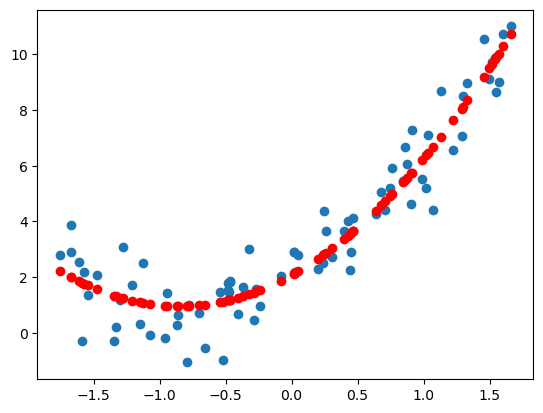

In [21]:
plt.scatter(X_train , y_train)
plt.scatter(X_train , regression.predict(X_train_poly) ,color = 'r')
plt.show()

 Best-fit line artık bu şekilde oldugu icin polinomsal olan bu dataset icin doğru tahminler yapmaya hazır

# Degree değişip deneyelim bakalım daha iyi bir başarı oranı yakalayabilir miyiz

In [22]:
poly = PolynomialFeatures(degree = 5, include_bias = True)
X_train_poly2 = poly.fit_transform(X_train)
X_test_poly2 = poly.transform(X_test)

In [23]:
regression.fit(X_train_poly2 , y_train)

LinearRegression()

In [24]:
y_pred2 = regression.predict(X_test_poly2)

In [25]:
r2 = r2_score(y_test , y_pred2)
print(r2) 

0.7351244165095399


%73 ' e indi model doğruluk oranı en iyisi 2 olan hali diyebiliriz şu ana kadar istersek daha da deneyerek bulabiliriz farklı şeyleri

# Yeni dataset geliyor ve bunda custromer satisfactionlar var bunlara bakarak modelimiz incentive tahminleri yapacak 

In [26]:
new_df = pd.read_csv('3-newdatas.csv')
new_df

,0
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397
...,...
195,2.879397
196,2.909548
197,2.939698
198,2.969849


In [27]:
new_df.rename(columns = {'0' : 'Customer Satisfaction' } , inplace = True )

In [28]:
X_new = new_df
X_new

,Customer Satisfaction
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397
...,...
195,2.879397
196,2.909548
197,2.939698
198,2.969849


In [29]:
X_new = scaler.fit_transform(X_new)

In [30]:
X_new_poly = poly.transform(X_new)

In [31]:
y_new = regression.predict(X_new_poly)

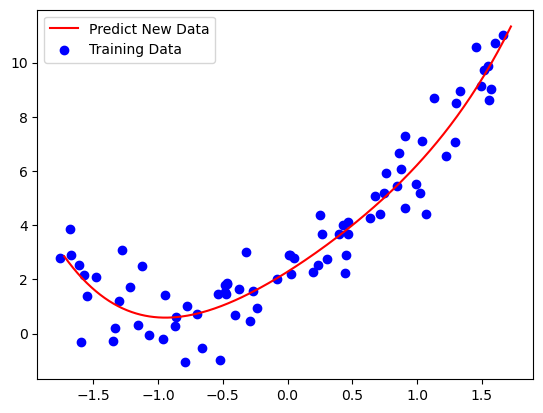

In [32]:
plt.plot(X_new , y_new , label = 'Predict New Data' , color = 'r')
plt.scatter(X_train , y_train , label = 'Training Data' , color = 'b')
plt.legend()
plt.show()

# PIPELINE !

In [33]:
def poly_regression(degree) : 
    poly_features = PolynomialFeatures(degree)
    lin_reg = LinearRegression()
    scaler = StandardScaler()
    pipeline = Pipeline([
        ('StandardScaler' , scaler),
        ('poly_features' , poly_features),
        ('lin_reg' , lin_reg)
    ])
    pipeline.fit(X_train , y_train)
    score = pipeline.score(X_test , y_test)
    print('R2 SCORE',score)

    y_pred = pipeline.predict(X_new)
    plt.plot(X_new , y_pred , color = 'r')
    plt.scatter(X_train , y_train , color = 'b')
    plt.show()

BU FONKSİYON BİZE EN UYGUN DEGREEYİ BULMADA YARDIMCI OLACAK BİR FONKSİYON 

R2 SCORE 0.2705652535622246


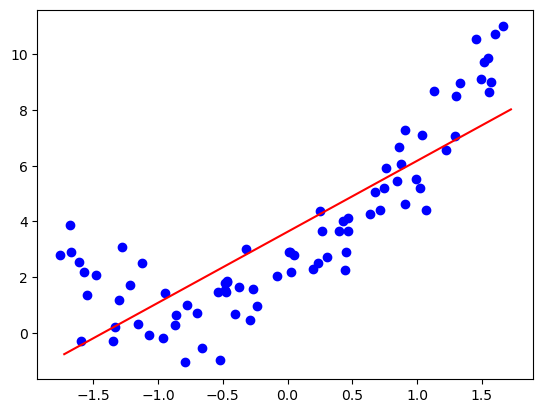

R2 SCORE 0.7685687698788558


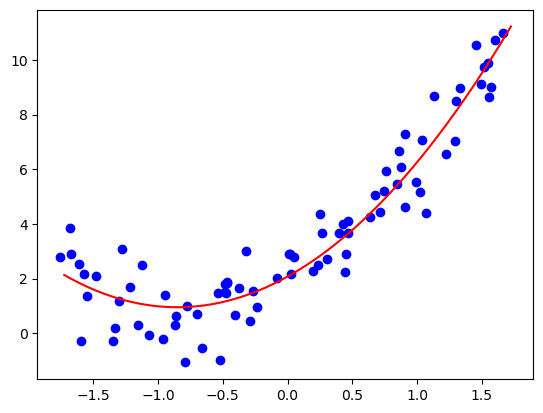

R2 SCORE 0.757344362140105


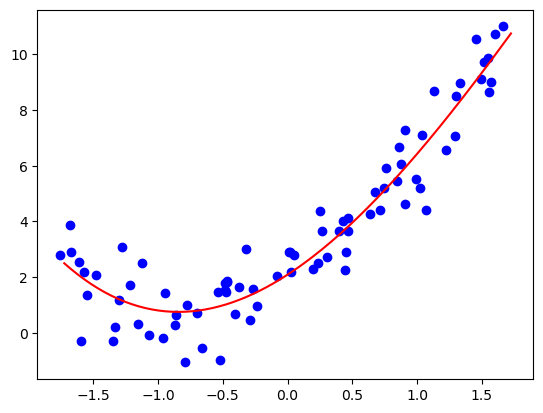

R2 SCORE 0.7355034443260413


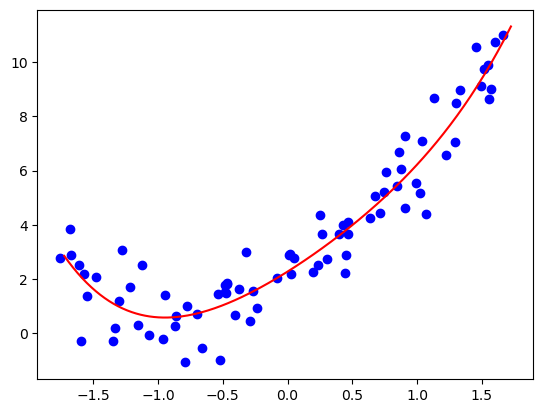

R2 SCORE 0.7351244165095399


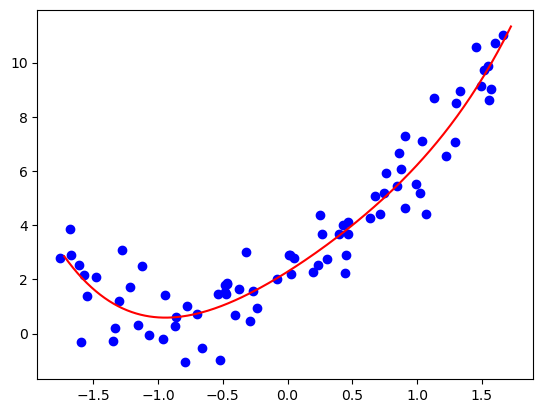

R2 SCORE 0.7343590482133429


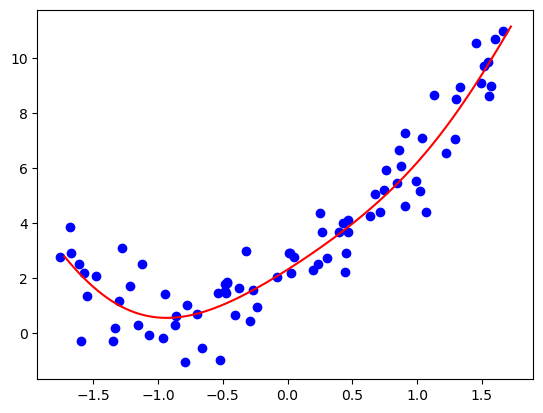

R2 SCORE 0.7347819263549453


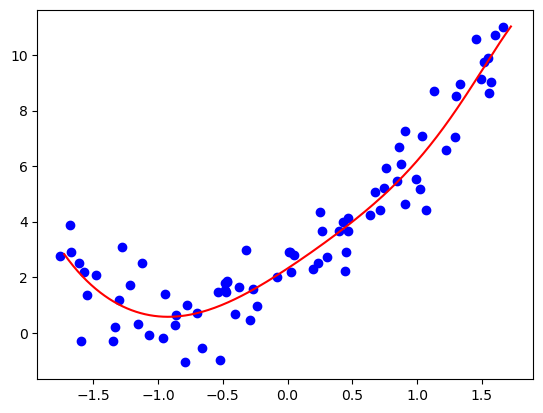

R2 SCORE 0.7411422099998382


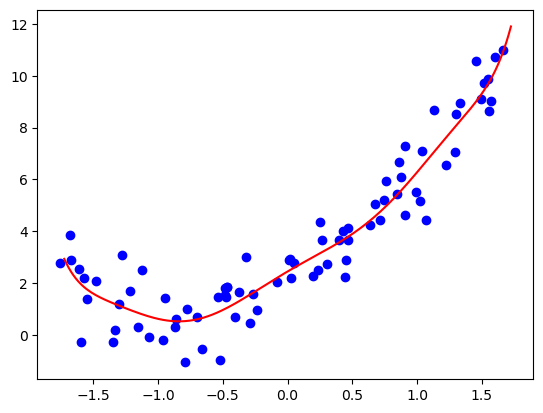

R2 SCORE 0.7310763879815942


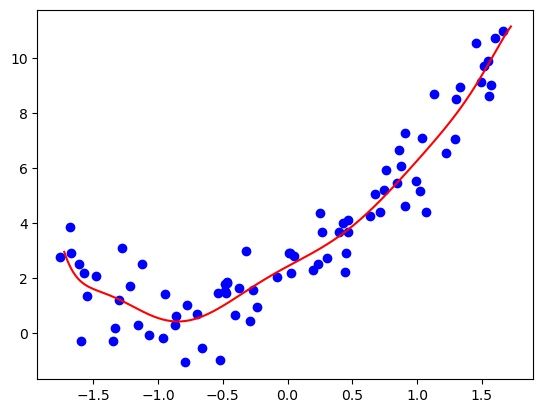

In [34]:
for item in [1,2,3,4,5,6,7,8,9] : 
    poly_regression(item) 
# Gorudumuz gibi en iyi sonuc 2 derecede 
# İdealden uzaklaştıkca best fit line saçma sapan bir hal almaya başlıyor